## Access this Notebook
You can launch this notebook in the US GHG Center JupyterHub by clicking the link below. If you are a new user, you should first sign up for the hub by filling out this [**request form**](https://docs.google.com/forms/d/e/1FAIpQLSdai8otCdrVQzJgev8mjDhzKyCg7jcrB3UeTXNHoCiaMKrkaQ/viewform) and providing the required information. 


Access the [**BlueFlux CO₂ and CH₄ Fluxes for Southern Florida Wetlands**](https://hub.ghg.center/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2FUS-GHG-Center%2Fghgc-docs&urlpath=lab%2Ftree%2Fghgc-docs%2Fuser_data_notebooks%2Fblueflux-ghgflux-daygrid-v1_User_Notebook.ipynb&branch=main) notebook in the US GHG Center JupyterHub (requires access).

## Table of Contents
- [Data Summary and Application](#data-summary-and-application)
- [Approach](#approach)
- [About the Data](#about-the-data)
- [Terminology](#terminology)
- [Install the Required Libraries](#install-the-required-libraries)
- [Query the STAC API](#query-the-stac-api)
- [Fetch Imagery Using Raster API](#fetch-imagery-using-raster-api)
- [Map Out Selected Tiles](#map-out-selected-tiles)
- [Calculate Zonal Statistics](#calculate-zonal-statistics)
- [Time-Series Analysis](#time-series-analysis)
- [Summary](#summary)

## Data Summary and Application
- **Spatial coverage**: Southern Florida (82.22 W, 79.96 W, 26.68 N, 24.48 N)
- **Spatial resolution**: 500m
- **Temporal extent**: February 25, 2000 - August 31, 2024
- **Temporal resolution**: Daily
- **Unit**: Micromoles of carbon dioxide per square meter per second (μmol CO₂/m2/s), Nanomoles of methane per square meter per second (nmol CH₄/m2/s)
- **Utility**: Climate Research

For more information, visit the [BlueFlux CO₂ and CH₄ Fluxes for Southern Florida Wetlands](https://earth.gov/ghgcenter/data-catalog/blueflux-ghgflux-daygrid-v1) data overview page.  

## Approach

1. Identify available dates and temporal frequency of observations for a given collection using the GHGC API `/stac` endpoint. The collection processed in this notebook is the BlueFlux CO₂ and CH₄ Fluxes for Southern Florida Wetlands data product.
2. Pass the STAC item into the raster API `/collections/{collection_id}/items/{item_id}/tilejson.json` endpoint.
3. Using `folium.plugins.DualMap`, visualize two tiles (side-by-side), allowing time point comparison.
4. After the visualization, perform zonal statistics for a given polygon.
5. Create a time-series analysis.

## About the Data
### BlueFlux CO₂ and CH₄ Fluxes for Southern Florida Wetlands

The BlueFlux dataset provides gridded estimates of carbon dioxide (CO₂) and methane (CH₄). This dataset is a product of NASA's BlueFlux campaign by NASA's Carbon Monitoring System that aims to develop a comprehensive database of greenhouse gas fluxes for mangrove and wetland ecosystems in Florida and the Caribbean. The dataset combines ground-based and airborne measurements to create daily flux estimates at 500-meter spatial resolution from February 2000 to August 2024. The data was generated using a machine learning approach that integrates eddy covariance (EC) measurements from both flux towers and NASA's Carbon Airborne Flux Experiment (CARAFE) platform. 

BlueFlux is particularly valuable for understanding the complex role of wetlands in the global carbon cycle. While mangroves and wetlands are highly efficient at sequestering atmospheric CO₂, they also produce significant amounts of methane through natural microbial processes in flooded soils. The BlueFlux data helps quantify this balance, showing that despite methane emissions, these ecosystems provide a net climate benefit by removing more greenhouse gases than they produce. 

For more information regarding this dataset, please visit the [BlueFlux CO₂ and CH₄ Fluxes for Southern Florida Wetlands](https://earth.gov/ghgcenter/data-catalog/blueflux-ghgflux-daygrid-v1) data overview page and the [ORNL DAAC BlueFlux user guide](https://daac.ornl.gov/CMS/guides/BlueFlux_Gridded_CO2_CH4.html).

## Terminology

Navigating data via the GHGC API, you will encounter terminology that is different from browsing in a typical filesystem. We'll define some terms here which are used throughout this notebook.

1.  `catalog`:    All datasets available at the `/stac` endpoint
2.  `collection`: A specific dataset, e.g. BlueFlux CO₂ and CH₄ Fluxes for Southern Florida Wetlands
3.  `item`:       One data file (i.e. granule) in the dataset, e.g. one daily file of carbon fluxes
4.  `asset`:      A variable available within the granule, e.g. net primary productivity or net ecosystem exchange
5.  `STAC API`:   **Sp**atio**T**emporal **A**sset **C**atalogs - Endpoint for fetching metadata about available datasets
6.  `Raster API`: Endpoint for fetching data itself, for imagery and statistics

# Install the Required Libraries
Required libraries are pre-installed on the GHG Center Hub. If you need to run this notebook elsewhere, please install them with this line in a code cell:

%pip install requests folium rasterstats pystac_client pandas matplotlib --quiet

In [1]:
# Import the following libraries
# For fetching from the Raster API
import requests
# For making maps
import folium
import folium.plugins
from folium import Map, TileLayer
# For talking to the STAC API
from pystac_client import Client
# For working with data
import pandas as pd
# For making time series
import matplotlib.pyplot as plt
# For formatting date/time data
import datetime
# Custom functions for working with GHGC data via the API
import ghgc_utils

## Query the STAC API
### STAC API Collection Names

Now, you must fetch the dataset from the [**STAC API**](https://earth.gov/ghgcenter/api/stac/) by defining its associated STAC API collection ID as a variable. 
The collection ID, also known as the **collection name**, for the BlueFlux CO₂ and CH₄ Fluxes for Southern Florida Wetlands dataset is [**blueflux-ghgflux-daygrid-v1**](https://earth.gov/ghgcenter/api/stac/collections/blueflux-ghgflux-daygrid-v1).*

**You can find the collection name of any dataset on the GHGC data portal by navigating to the dataset landing page within the data catalog. The collection name is the last portion of the dataset landing page's URL.*

In [2]:
# Provide the STAC and RASTER API endpoints
# The endpoint is referring to a location within the API that executes a request on a data collection nesting on the server.

# The STAC API is a catalog of all the existing data collections that are stored in the GHG Center.
STAC_API_URL = "https://dev.ghg.center/api/stac"

# The RASTER API is used to fetch collections for visualization
RASTER_API_URL = "https://dev.ghg.center/api/raster"

# The collection name is used to fetch metadata from the STAC API.
collection_name = "blueflux-ghgflux-daygrid-v1"

In [ ]:
# Fetch the collection from the STAC API using the appropriate endpoint
# The 'pystac_client' library makes an HTTP request
catalog = Client.open(STAC_API_URL)
collection = catalog.get_collection(collection_name)

# Print the properties of the collection to the console
collection

<CollectionClient id=blueflux-ghgflux-daygrid-v1>

Examining the contents of our `collection` under the `temporal` variable, we see that the data is available from February 25, 2000 - August 31, 2024. By looking at the `dashboard:time density`, we observe that the periodic frequency of these observations is daily.

In [4]:
# NOTE: searching for all items can take several minutes. Therefore, this block can be commented out.
# This block is to show the total number of items and isn't integral for the remaining notebook.

# items = list(collection.get_items())  # Convert the iterator to a list
# print(f"Found {len(items)} items")

In [5]:
# The search function can be used to find data within a specific time frame, e.g. January 2022.
search = catalog.search(
    collections=collection_name,
    datetime=['2022-01-01T00:00:00Z','2022-01-31T00:00:00Z']
)
# Take a look at the items we found
for item in search.item_collection():
    print(item)

<Item id=blueflux-ghgflux-daygrid-v1-2022-01-31>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-30>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-29>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-28>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-27>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-26>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-25>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-24>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-23>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-22>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-21>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-20>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-19>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-18>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-17>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-16>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-15>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-14>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-13>
<Item id=blueflux-ghgflux-daygrid-v1-2022-01-12>
<Item id=blueflux-gh

In [6]:
# Examine the first item in the search results
# Keep in mind that a list starts from 0, 1, 2... therefore items[0] is referring to the first item in the list/collection
items = search.item_collection()
items[0]

<Item id=blueflux-ghgflux-daygrid-v1-2022-01-31>

In [7]:
# Restructure our items into a dictionary where keys are the datetime items
# Then we can query more easily by date/time, e.g. "2020-05-20"
items_dict = {item.properties["datetime"][:10]: item for item in items}

In [8]:
# Before we go further, let's pick which asset to focus on for the remainder of the notebook.
# We'll focus on methane flux, so our asset of interest is:
asset_name = "fch4mean"

## Creating Maps Using Folium

You will now explore changes in the land atmosphere `Methane Flux` at a given location. You will visualize the outputs on a map using `folium`.

### Fetch Imagery Using Raster API
Here we get information from the `Raster API` which we will add to our map in the next section.

In [9]:
# Specify two date/times that you would like to visualize, using the format of items_dict.keys()
dates = ["2022-01-01","2022-01-26"]

Below, we use some statistics of the raster data to set upper and lower limits for our color bar. These are saved as  `rescale_values`, and will be passed to the Raster API in the following step(s).

In [10]:
# Extract collection name and item ID for the first date
observation_date_1 = items_dict[dates[0]]
collection_id = observation_date_1.collection_id
item_id = observation_date_1.id
# Select relevant asset (CH₄ Mean)
object = observation_date_1.assets[asset_name]
raster_bands = object.extra_fields.get("raster:bands", [{}])
# Print raster bands' information
raster_bands

[{'scale': 1.0,
  'nodata': -9999.0,
  'offset': 0.0,
  'sampling': 'area',
  'data_type': 'float32',
  'histogram': {'max': 142.18939208984375,
   'min': -37.5793342590332,
   'count': 11,
   'buckets': [64, 279, 23725, 30485, 30177, 14017, 2254, 332, 50, 10]},
  'statistics': {'mean': 32.92122730366002,
   'stddev': 18.90949800094003,
   'maximum': 142.18939208984375,
   'minimum': -37.5793342590332,
   'valid_percent': 35.49578502212513}}]

In [11]:
# Use raster band statistics to generate an appropriate color bar range.
rescale_values = {
    "max": raster_bands[0].get("histogram", {}).get("max"),
    "min": raster_bands[0].get("histogram", {}).get("min"),
}

print(rescale_values)


{'max': 142.18939208984375, 'min': -37.5793342590332}


Now, you will pass the `item id`, `collection name`, `asset name`, and the `rescale values` to the Raster API endpoint, along with a colormap. This step is done twice, one for each date/time you will visualize, and tells the Raster API which collection, item, and asset you want to view, specifying the colormap and colorbar ranges to use for visualization. The API returns a JSON with information about the requested image. Each image will be referred to as a tile.

In [12]:
# Choose a colormap for displaying the data
# Make sure to capitalize per Matplotlib standard colormap names
# For more information on Colormaps in Matplotlib, please visit https://matplotlib.org/stable/users/explain/colors/colormaps.html
color_map = "viridis"

In [13]:
# Make a GET request to retrieve information for your first date/time
observation_date_1_tile = requests.get(
    f"{RASTER_API_URL}/collections/{collection_id}/items/{item_id}/tilejson.json?"
    f"&assets={asset_name}"
    f"&color_formula=gamma+r+1.05&colormap_name={color_map.lower()}"
    f"&rescale={rescale_values['min']},{rescale_values['max']}"
).json()

# Print the properties of the retrieved granule to the console
observation_date_1_tile

{'tilejson': '2.2.0',
 'version': '1.0.0',
 'scheme': 'xyz',
 'tiles': ['https://dev.ghg.center/api/raster/collections/blueflux-ghgflux-daygrid-v1/items/blueflux-ghgflux-daygrid-v1-2022-01-01/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?assets=fch4mean&color_formula=gamma+r+1.05&colormap_name=viridis&rescale=-37.5793342590332%2C142.18939208984375'],
 'minzoom': 0,
 'maxzoom': 24,
 'bounds': [-82.22292001512315,
  24.477078743632426,
  -79.96457998487683,
  26.68125408107461],
 'center': [-81.09375, 25.579166412353516, 0]}

In [14]:
# Repeat the above for your second date/time
# Note that we do not calculate new rescale_values for this tile - 
# We want date tiles 1 and 2 to have the same colorbar range for visual comparison.
observation_date_2 = items_dict[dates[1]]
# Extract collection name and item ID
collection_id = observation_date_2.collection_id
item_id = observation_date_2.id
# Make a GET request to retrieve tile information
observation_date_2_tile = requests.get(
    f"{RASTER_API_URL}/collections/{collection_id}/items/{item_id}/tilejson.json?"
    f"&assets={asset_name}"
    f"&color_formula=gamma+r+1.05&colormap_name={color_map.lower()}"
    f"&rescale={rescale_values['min']},{rescale_values['max']}"
).json()

# Print the properties of the retrieved granule to the console
observation_date_2_tile

{'tilejson': '2.2.0',
 'version': '1.0.0',
 'scheme': 'xyz',
 'tiles': ['https://dev.ghg.center/api/raster/collections/blueflux-ghgflux-daygrid-v1/items/blueflux-ghgflux-daygrid-v1-2022-01-26/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?assets=fch4mean&color_formula=gamma+r+1.05&colormap_name=viridis&rescale=-37.5793342590332%2C142.18939208984375'],
 'minzoom': 0,
 'maxzoom': 24,
 'bounds': [-82.22292001512315,
  24.477078743632426,
  -79.96457998487683,
  26.68125408107461],
 'center': [-81.09375, 25.579166412353516, 0]}

## Map Out Selected Tiles
For this example, we'll look at CH₄ Mean over Southern Florida Wetlands. 

First, let's determine an area of interest (AOI) to visualize via GeoJSON.

In [15]:
# Set a name for the AOI to use in plots later
aoi_name = "South Florida"
# The Area of Interest (AOI) is set to Southern Florida Wetlands
aoi = {
    "type": "Feature",
    "properties": {},
    "geometry": {
        "coordinates": [
            [
                # [longitude, latitude]
                [-82.22, 24.48],  
                [-82.22, 26.68],  
                [-79.96, 26.68],  
                [-79.96, 24.48],  
                [-82.22, 24.48]   # Closing the polygon at the Southwest Bounding Coordinate
            ]
        ],
        "type": "Polygon",
    },
}


In [16]:
# Initialize the map, specifying the center of the map and the starting zoom level.
# 'folium.plugins' allows mapping side-by-side via 'DualMap'
# Map is centered on the position specified by "location=(lat,lon)"
map_ = folium.plugins.DualMap(location=(26.68,-79.96 ), zoom_start=7)


# Define the first map layer using the tile fetched for the first date
# The TileLayer library helps in manipulating and displaying raster layers on a map
map_layer_observation_date_1 = TileLayer(
    tiles=observation_date_1_tile["tiles"][0], # Path to retrieve the tile
    attr="GHG", # Set the attribution
    opacity=0.8, # Adjust the transparency of the layer
    name=f"{dates[0]} fch4mean", # Title for the layer
    overlay= True, # The layer can be overlaid on the map
    legendEnabled = True # Enable displaying the legend on the map
)

# Add the first layer to the Dual Map
# This will appear on the left side, specified by 'm1'
map_layer_observation_date_1.add_to(map_.m1)


# Define the second map layer using the tile fetched for the second date
map_layer_observation_date_2 = TileLayer(
    tiles=observation_date_2_tile["tiles"][0], # Path to retrieve the tile
    attr="GHG", # Set the attribution
    opacity=0.8, # Adjust the transparency of the layer
    name=f"{dates[1]} fch4mean", # Title for the layer
    overlay= True, # The layer can be overlaid on the map
    legendEnabled = True # Enable displaying the legend on the map
)

# Add the second layer to the Dual Map
# This will appear on the left side, specified by 'm2'
map_layer_observation_date_2.add_to(map_.m2)

# Display data marker on each map
folium.Marker((26.68,-79.96), tooltip=aoi_name).add_to(map_)
# Display AOI on each map
folium.GeoJson(aoi, name=f"{aoi_name} AOI",style_function=lambda feature: {"fillColor": "none"}).add_to(map_)
# Add a layer control to switch between map layers
folium.LayerControl(collapsed=False).add_to(map_)

# Add colorbar
# We can use 'generate_html_colorbar' from the 'ghgc_utils' module 
# to create an HTML colorbar representation.
legend_html = ghgc_utils.generate_html_colorbar(color_map,rescale_values,label='fch4mean (nmol CH₄/m2/s)',dark=True)

# Add colorbar to the map
map_.get_root().html.add_child(folium.Element(legend_html))

# Visualize the Dual Map
map_

## Calculate Zonal Statistics
To perform zonal statistics, we will use our previously defined AOI for Southern Florida. 

We'll generate statistics for the data in our AOI using a function from the `ghgc_utils` module, which fetches the data and its statistics from the `Raster API`.

In [17]:
%%time
# %%time = Wall time (execution time) for running the code below

# Statistics will be returned as a Pandas DataFrame
df = ghgc_utils.generate_stats(items,aoi,url=RASTER_API_URL,asset=asset_name)
# Print the first five rows of statistics from our DataFrame
df.head(5)

Generating stats...
Done!
CPU times: user 121 ms, sys: 48.9 ms, total: 170 ms
Wall time: 32.2 s


,datetime,min,max,mean,count,sum,std,median,majority,minority,unique,histogram,valid_percent,masked_pixels,valid_pixels,percentile_2,percentile_98,date
0,2022-01-31T00:00:00Z,-39.61635589599609375000,122.21352386474609375000,30.33488082885742187500,101037.39843750000000000000,3064957.50000000000000000000,18.66093184161138296417,27.43743324279785156250,22.19587135314941406250,-39.61635589599609375000,90746.00000000000000000000,"[[74, 238, 10250, 35671, 26582, 19281, 7243, 1...",35.28000000000000113687,185549.00000000000000000000,101155.00000000000000000000,3.86966156959533691406,72.64569091796875000000,2022-01-31 00:00:00+00:00
1,2022-01-30T00:00:00Z,-41.00300598144531250000,122.38569641113281250000,30.38051223754882812500,100974.39843750000000000000,3067654.00000000000000000000,18.72250180864217128374,27.53126144409179687500,15.23850822448730468750,-41.00300598144531250000,90689.00000000000000000000,"[[61, 219, 8423, 35885, 27239, 19728, 7551, 16...",35.25999999999999801048,185612.00000000000000000000,101092.00000000000000000000,3.79161334037780761719,73.16805267333984375000,2022-01-30 00:00:00+00:00
2,2022-01-29T00:00:00Z,-36.46431350708007812500,127.92996978759765625000,30.40985870361328125000,100890.39843750000000000000,3068062.75000000000000000000,18.71640708156800059214,27.65876388549804687500,50.06641006469726562500,-36.46431350708007812500,90611.00000000000000000000,"[[117, 304, 19624, 33324, 25599, 16071, 4925, ...",35.22999999999999687361,185696.00000000000000000000,101008.00000000000000000000,3.69644880294799804688,72.62789154052734375000,2022-01-29 00:00:00+00:00
3,2022-01-28T00:00:00Z,-35.23519897460937500000,128.19352722167968750000,30.44643974304199218750,100806.39843750000000000000,3069196.00000000000000000000,18.64740895126459818698,27.79669952392578125000,41.79220199584960937500,-35.23519897460937500000,90554.00000000000000000000,"[[124, 323, 21906, 32235, 25280, 15520, 4618, ...",35.20000000000000284217,185780.00000000000000000000,100924.00000000000000000000,3.73589730262756347656,72.53171539306640625000,2022-01-28 00:00:00+00:00
4,2022-01-27T00:00:00Z,-34.76666259765625000000,123.42082977294921875000,30.38496780395507812500,101019.20312500000000000000,3069465.25000000000000000000,18.58151760838870103498,27.77589225769042968750,40.51256179809570312500,-33.52347946166992187500,90725.00000000000000000000,"[[118, 300, 19384, 32048, 25190, 17182, 5647, ...",35.28000000000000113687,185566.00000000000000000000,101138.00000000000000000000,3.69582176208496093750,72.12689208984375000000,2022-01-27 00:00:00+00:00


## Time-Series Analysis
You can now explore the Methane Flux values using this data collection (January 2021 - December 2023) for the Southern Florida Wetlands region. You can plot the data set using the code below:

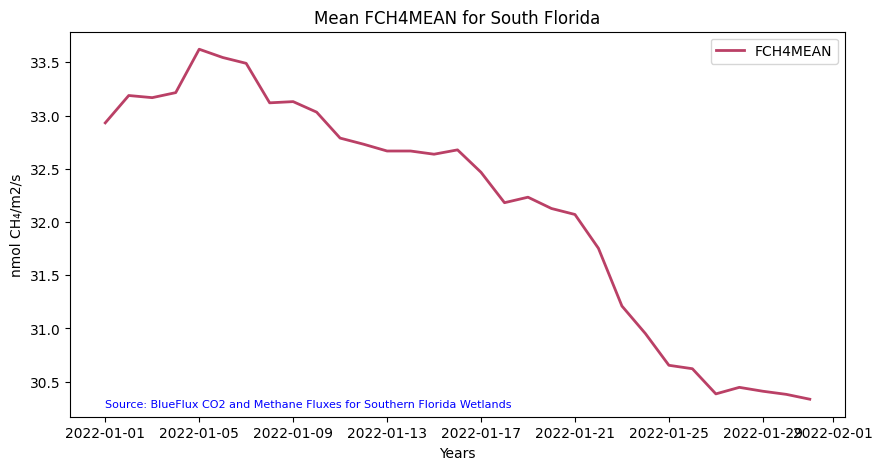

In [18]:
# Determine the width and height of the plot using the 'matplotlib' library
# Figure size: 20 representing the width, 10 representing the height
fig = plt.figure(figsize=(10, 5)) 

# Change 'which_stat' below if you would rather look at a different statistic, like minimum or mean.
which_stat = "mean"

# Plot the time series analysis of the daily CH₄ Mean Values for Southern Florida Wetlands
plt.plot(
    df["date"], # X-axis: date
    df[which_stat], # Y-axis: CH4 Mean value
    color="#BA4066", # Line color in hex format
    linestyle="-", # Line style
    linewidth=2, # Line width
    label=asset_name.upper(), # Legend label
)

# Display legend
plt.legend()

# Insert label for the X-axis
plt.xlabel("Years")

# Insert label for the Y-axis
plt.ylabel("nmol CH₄/m2/s")

# Insert title for the plot
plt.title(f"{which_stat.capitalize()} {asset_name.upper()} for {aoi_name}")

# Add data citation
plt.text(
    df["date"].iloc[-1],           # X-coordinate of the text
    df[which_stat].min(),                  # Y-coordinate of the text

    # Text to be displayed
    f"Source: {collection.title}",                  
    fontsize=8,                             # Font size
    horizontalalignment="left",              # Horizontal alignment
    verticalalignment="top",                 # Vertical alignment
    color="blue",                            # Text color
)

plt.show()

## Summary

In this notebook we have successfully completed the following steps for the STAC collection for the BlueFlux CO₂ and CH₄ Fluxes for Southern Florida Wetlands dataset:

1.  Install and import the necessary libraries 
2.  Fetch the collection from STAC collections using the appropriate endpoints
3.  Count the number of existing granules within the collection
4.  Map and compare the Methane Flux (CH₄ Mean) levels over the Southern Florida Wetlands area for two distinctive days
5.  Create a table that displays the minimum, maximum, and sum of the Methane Flux (CH₄ Mean) values for a specified region
6.  Generate a time-series graph of the Methane Flux (CH₄ Mean) values for a specified region

If you have any questions regarding this user notebook, please contact us using the [feedback form](https://docs.google.com/forms/d/e/1FAIpQLSeVWCrnca08Gt_qoWYjTo6gnj1BEGL4NCUC9VEiQnXA02gzVQ/viewform).